# A Bayesian Network for Modeling and Explaining Diabaese Prediction


## Abstract
This project presents a Bayesian Network designed to model and explain the prediction of diabetes based on various health and lifestyle factors. The network incorporates variables such as age, body mass index (BMI), physical activity, family history, and blood glucose levels to provide a probabilistic framework for understanding the relationships between these factors and the likelihood of developing diabetes. By leveraging the principles of Bayesian inference, the model aims to offer insights into the contributing factors of diabetes, enabling healthcare professionals to make informed decisions regarding prevention and treatment strategies. The network also facilitates explainability by allowing users to visualize how changes in specific variables impact the overall risk of diabetes, thereby enhancing interpretability and trust in the predictions made by the model.

## Dataset Overview
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.


The dataset contains the following attributes:
| Attribute                     | Description                                      |
|-------------------------------|--------------------------------------------------|
| Pregnancies                   | Number of times pregnant                         |
| Glucose                       | Plasma glucose concentration a 2 hours in an oral glucose tolerance test |
| BloodPressure                 | Diastolic blood pressure (mm Hg)                 |
| SkinThickness                 | Triceps skin fold thickness (mm)                 |
| Insulin                       | 2-Hour serum insulin (mu U/ml)                   |
| BMI                           | Body mass index (weight in kg/(height in m)^2)
| DiabetesPedigreeFunction      | Diabetes pedigree function                        |
| Age                           | Age (years)                                      |
| Outcome                       | Class variable (0 or 1) indicating if the patient has diabetes (1) or not (0) |
The dataset consists of 768 instances, with 500 instances labeled as non-diabetic (0) and 268 instances labeled as diabetic (1). The features include both continuous and categorical variables, which will be used to construct the Bayesian Network for predicting diabetes.


## Importing Libraries 

In [2]:
import pgmpy as pg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator,HillClimbSearch,TreeSearch,BDeu,K2,BIC,BDs,AIC
from pgmpy.independencies import IndependenceAssertion
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer
import networkx as nx


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## EDA

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process. It helps us to better understand the given data, so that we can make sense out of it. If EDA is not done properly, it can hamper the further steps in the machine learning model building process. On the other hand, if done well, it may improve the efficacy of everything we do next. In order to perform EDA, we need to follow a systematic approach that involves several techniques. The following are some of the key steps involved in EDA:

1. Data Sourcing: This is the very first step of EDA, where we access data and load it into our system.

2. Data Cleaning: Once we have the data, we need to clean it by removing any inconsistencies, missing values, or outliers.

3. Analysing Dataset Characteristics: This step involves understanding the structure and properties of the dataset, such as data types, distributions, and relationships between variables.
   
In here We Analyse the dataset before and after cleaning it. So we can have a better understanding of cleaning process effects on the dataset.

On Data Analysis we do the following steps: 

1. statistical summary of the dataset
2. plotting distributions of features
3. checking for missing values
4. checking for zero values in features where it is not possible
5. scatter plot of each feature vs Outcome
6. pair plot of features
7. heatmap of correlation matrix

## Data Sourcing

In [3]:
# merging two csv files into one
df = pd.read_csv('data/diabetes.csv',sep=',')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Analysing Dataset Characteristics before Cleaning

### statistics lookup of each feature

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

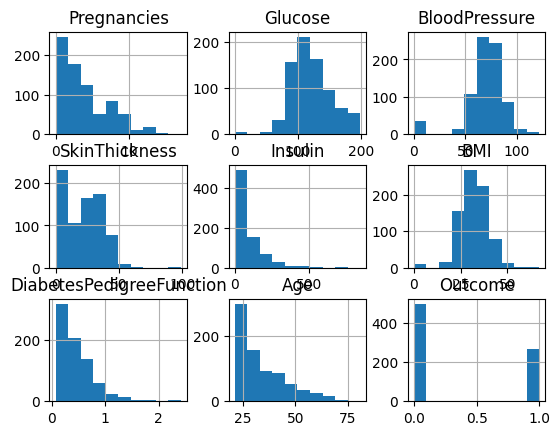

In [33]:
df.hist()

In [4]:
statistic = df.describe().round(2)
statistic.loc['range'] = statistic.loc['max'] - statistic.loc['min']
statistic.loc['variance'] = df.var().round(2)
statistic


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00
range,17.00,199.00,122.00,99.00,846.00,67.10,2.34,60.00,1.00
variance,11.35,1022.25,374.65,254.47,13281.18,62.16,0.11,138.30,0.23


### Correlation Matrix

In [5]:

## Corelleation Matrix
correlation_matrix = df.corr()
correlation_matrix


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


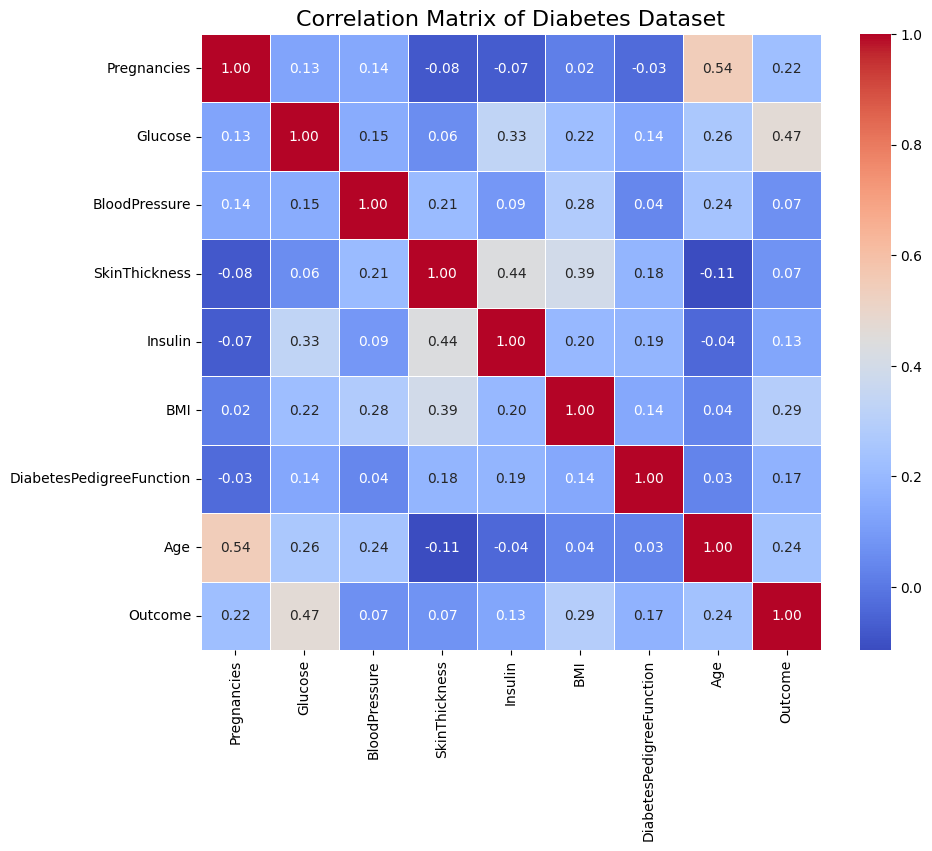

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidth=.5)
plt.title('Correlation Matrix of Diabetes Dataset', fontsize=16)
plt.savefig('correlation_matrix.png')
plt.show()

### Box Plot of each feature 

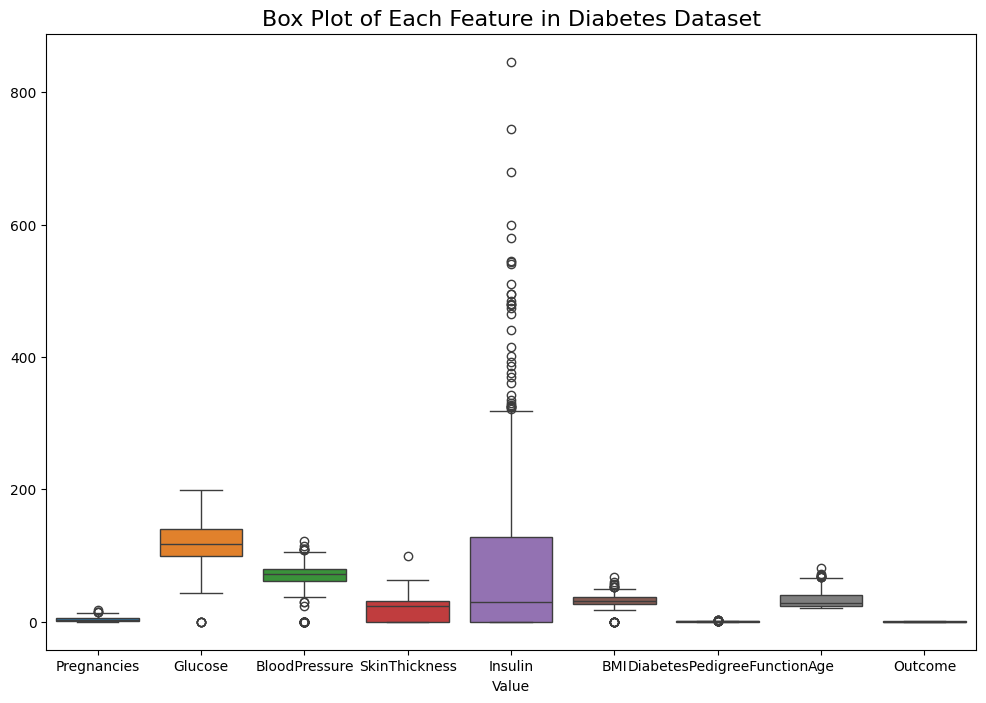

In [7]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.title('Box Plot of Each Feature in Diabetes Dataset', fontsize=16)
plt.xlabel('Value')
plt.savefig('box_plot_features.png')
plt.show()

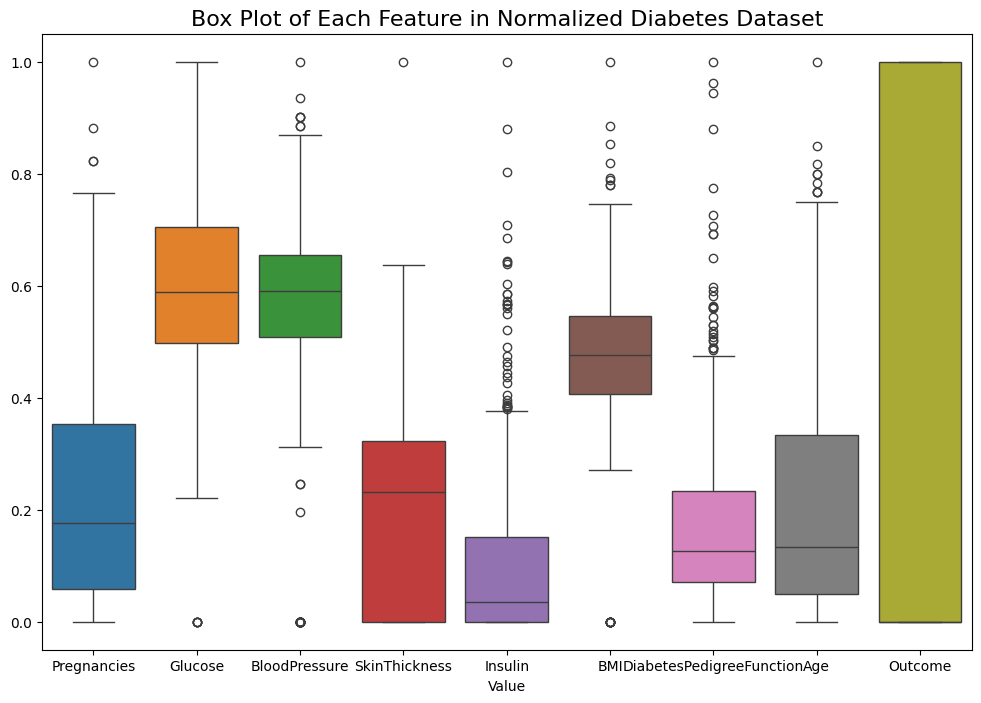

In [8]:
# normalize and check box plot again
scaler = MinMaxScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
plt.figure(figsize=(12, 8))
sns.boxplot(data=normalized_data)
plt.title('Box Plot of Each Feature in Normalized Diabetes Dataset', fontsize=16)
plt.xlabel('Value')
plt.savefig('box_plot_normalized_features.png')
plt.show()

### Scatter Plot of each feature vs Outcome

<Figure size 640x480 with 0 Axes>

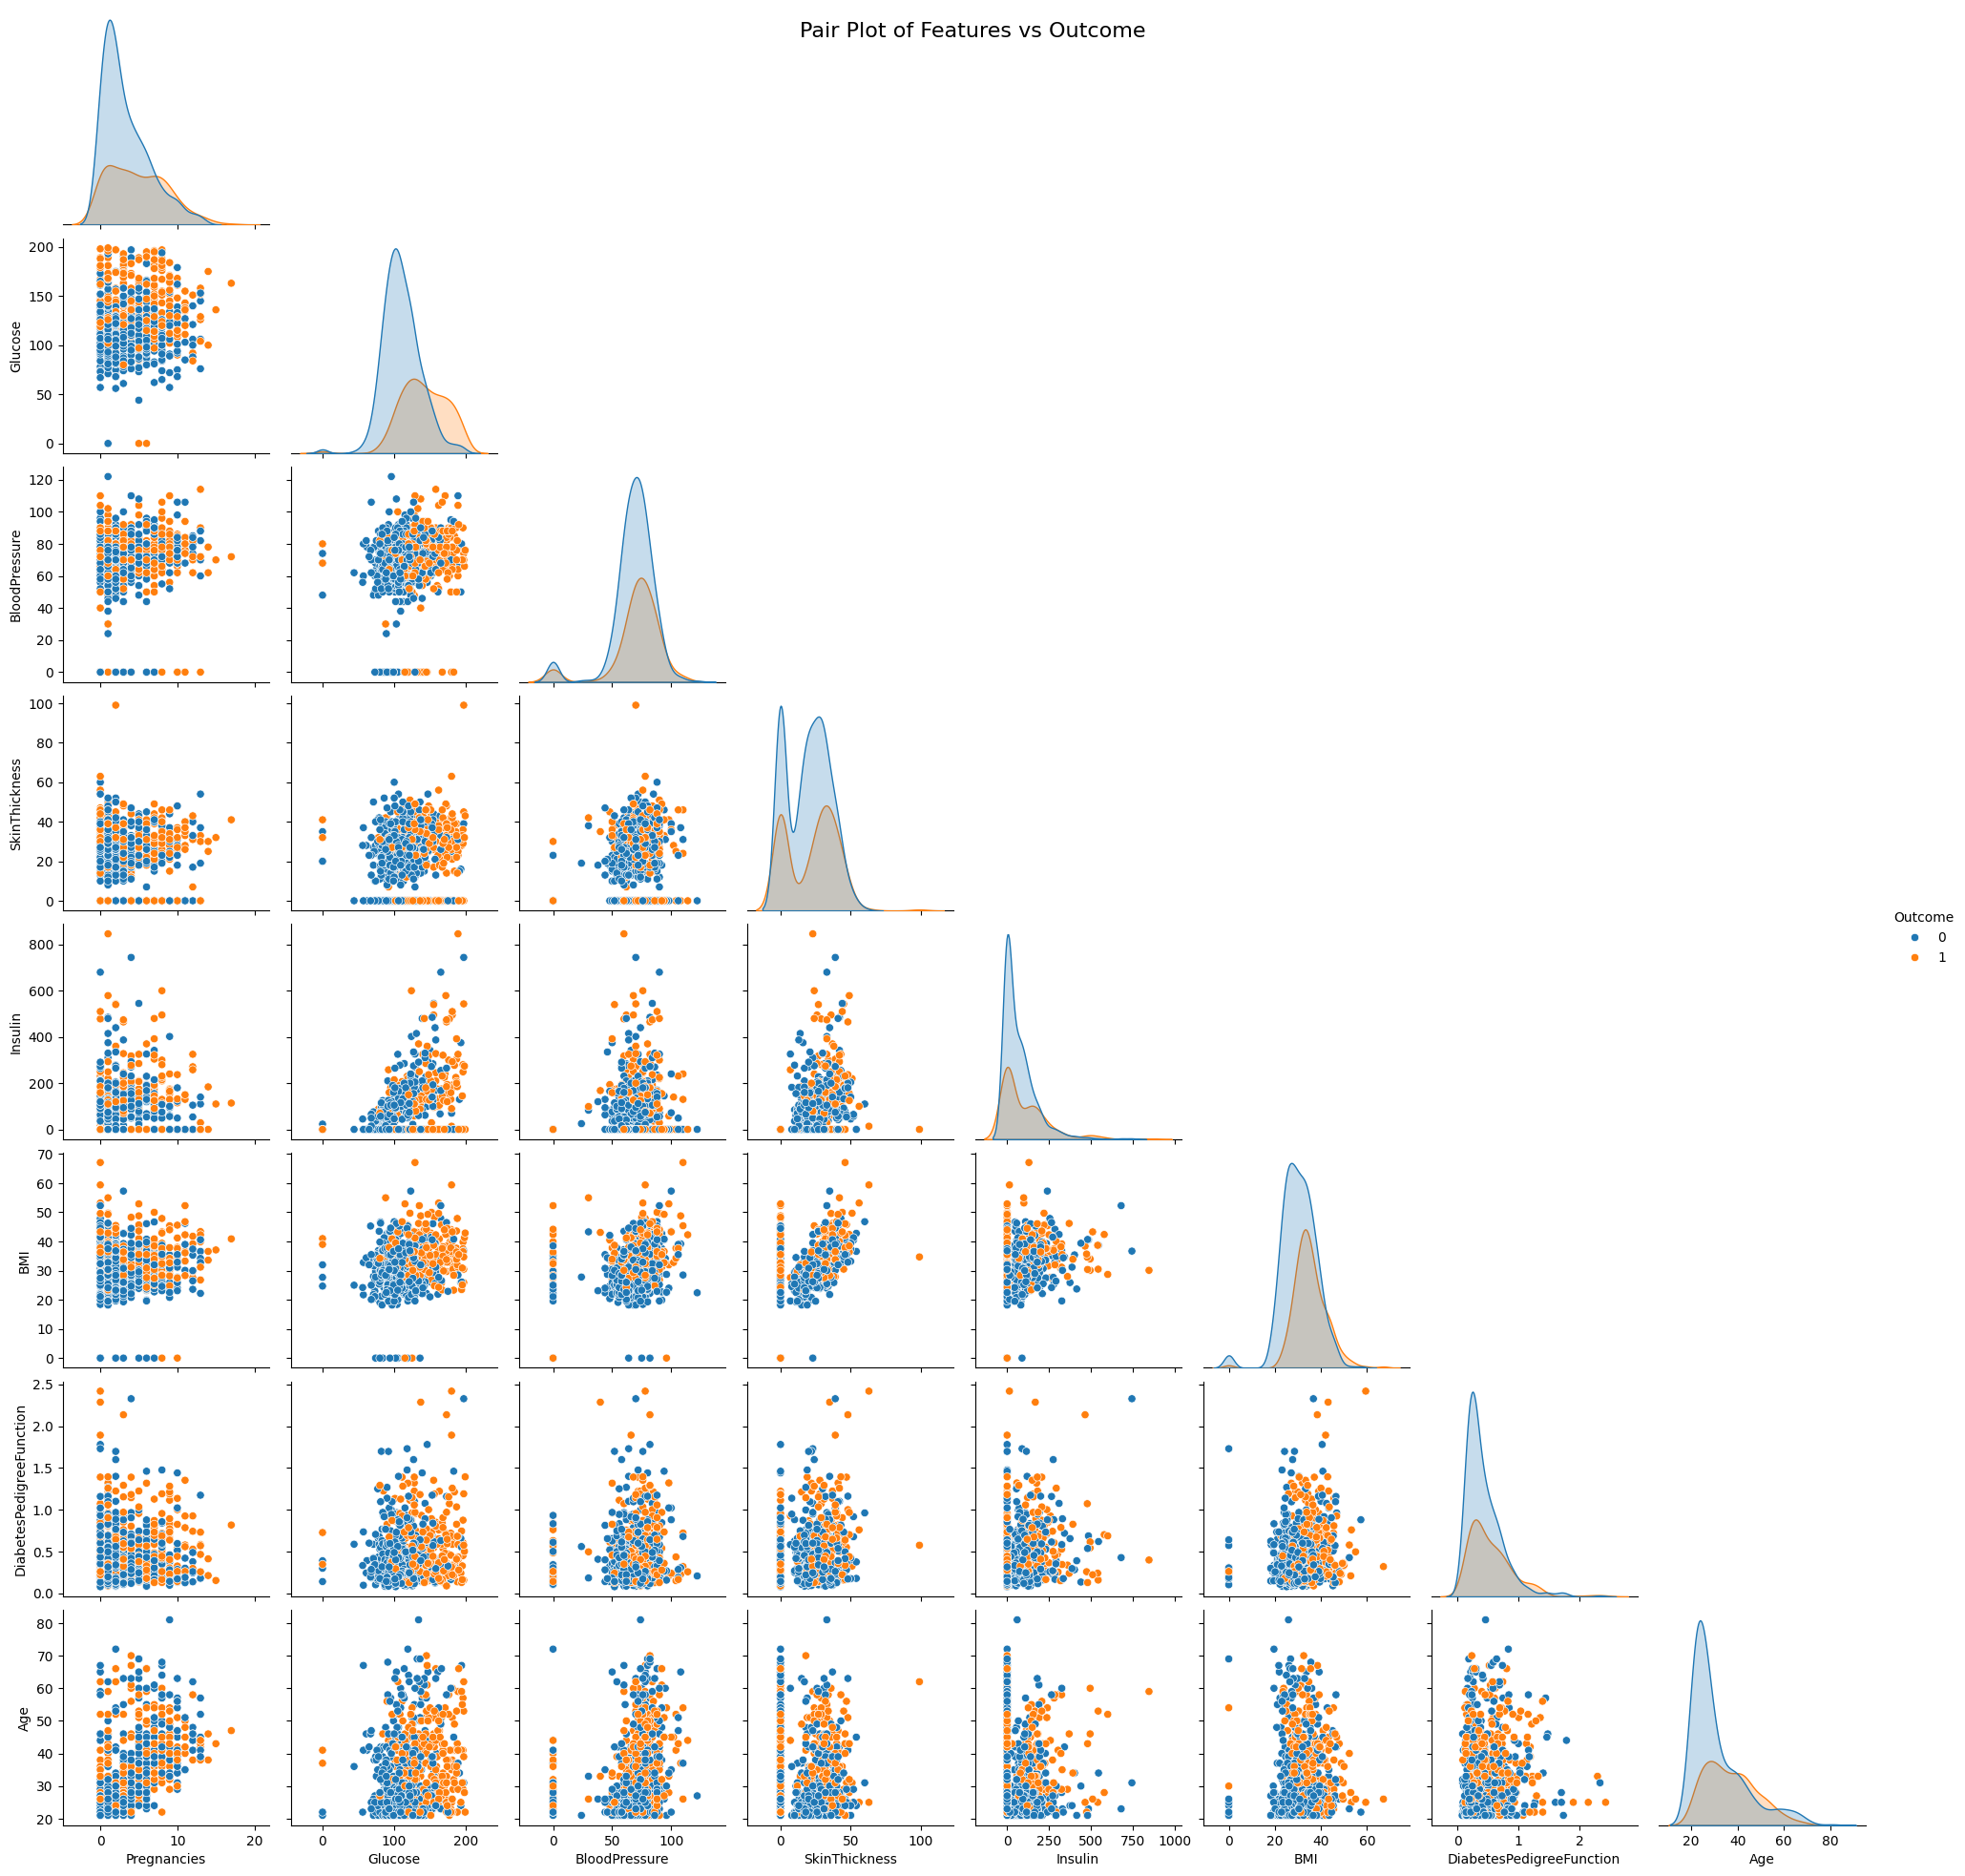

In [9]:
plt.figure()
sns.pairplot(
    df,
    vars=[df.columns[i] for i in range(len(df.columns)-1)],
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair Plot of Features vs Outcome', fontsize=16)
plt.savefig('pair_plot_features_vs_outcome.png')
plt.show()


### Pie Chart of Outcome feature

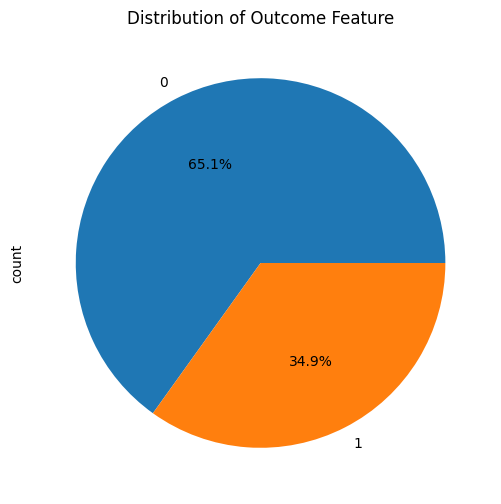

In [10]:
df["Outcome"].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Outcome Feature')
plt.savefig('outcome_distribution_pie_chart.png')
plt.show()

### Check for missing Values

In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Check for zero values in features where it is not possible

In [12]:
zero_value_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI','Age']
zero_value_counts = {col: (df[col] == 0).sum() for col in zero_value_columns}
zero_value_counts

{'Glucose': 5, 'BloodPressure': 35, 'SkinThickness': 227, 'BMI': 11, 'Age': 0}

## Preprocessing

In this section, we will preprocess the dataset to prepare it for building the Bayesian Network model. The preprocessing steps include handling missing values, and discretizing continuous variables into numeric bins.

for handling missing values we can use three methods:
1. Remove rows with missing values
2. Impute missing values with mean/median/mode
3. Use advanced imputation techniques like KNN imputation or regression imputation

if we use firsy method we will lose a lot of data, so
we will use Impute missing values with mean and  KNN imputation for handling missing values. After that we will compare the results of each method.

for handling discretization we can use five methods:
1. Equal Width Binning
2. Quantile Binning
3. K-Means Binning
4. round Values to nearest integer

we will user K-Means and Quantile  Binning for discretization of continuous variables. After that we will compare the results of each method.

Challenges:
1. after handling missing values with mean imputaion or knn imputaion we will create new continuous columns, so we need to threat them diffrently in discretization step. We have two options here:
   - we can discretize them along with other continuous columns with same methods.
   - we can discretize them separately using round values to nearest integer method.
we will use the second option for discretization of imputed columns.

At the end of this section we will have four different preprocessed datasets to compare the results of each method.

### Handling Missing Values

#### Imputing missing values with mean

In [13]:
df_mean_imputed = df.copy()
for col in zero_value_columns:
    mean_value = df_mean_imputed[col].replace(0, np.nan).mean()
    df_mean_imputed[col] = df_mean_imputed[col].replace(0, mean_value)
df_mean_imputed[zero_value_columns].isnull().sum()
df_mean_imputed

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,0,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,0,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,0,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180,32.9,0.171,63,0
764,2,122.0,70.0,27.00000,0,36.8,0.340,27,0
765,5,121.0,72.0,23.00000,112,26.2,0.245,30,0
766,1,126.0,60.0,29.15342,0,30.1,0.349,47,1


#### Imputing missing values with KNN imputation

In [14]:
df_knn_imputed = df.copy()
df_knn_imputed[zero_value_columns] = df_knn_imputed[zero_value_columns].replace(0, np.nan)
imputer = KNNImputer(n_neighbors=5)
df_knn_imputed[zero_value_columns] = imputer.fit_transform(df_knn_imputed[zero_value_columns])
df_knn_imputed[zero_value_columns].isnull().sum()
df_knn_imputed

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,0,33.6,0.627,50.0,1
1,1,85.0,66.0,29.0,0,26.6,0.351,31.0,0
2,8,183.0,64.0,23.4,0,23.3,0.672,32.0,1
3,1,89.0,66.0,23.0,94,28.1,0.167,21.0,0
4,0,137.0,40.0,35.0,168,43.1,2.288,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180,32.9,0.171,63.0,0
764,2,122.0,70.0,27.0,0,36.8,0.340,27.0,0
765,5,121.0,72.0,23.0,112,26.2,0.245,30.0,0
766,1,126.0,60.0,33.4,0,30.1,0.349,47.0,1


### Descretization of Continuous Variables

first we need to check ranges again.

In [15]:
statistic_mean = df_mean_imputed.describe().round(2)
statistic_mean

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.69,72.41,29.15,79.80,32.46,0.47,33.24,0.35
std,3.37,30.44,12.10,8.79,115.24,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,0.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,0.00,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.20,29.15,30.50,32.40,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [16]:
statistic_knn = df_knn_imputed.describe().round(2)
statistic_knn

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.61,72.32,29.09,79.80,32.42,0.47,33.24,0.35
std,3.37,30.49,12.19,9.43,115.24,6.89,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,0.00,18.20,0.08,21.00,0.00
25%,1.00,99.00,64.00,23.00,0.00,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,30.50,32.14,0.37,29.00,0.00
75%,6.00,140.25,80.00,35.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


#### Descritize columns with imputed values by rounding to nearest integer
we will use this method for columns that descrete values before imputation like Gluciose, BloodPressure, SkinThickness, BMI.

In [17]:
columns_to_discretize_round = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']
df_mean_imputed[columns_to_discretize_round] = df_mean_imputed[columns_to_discretize_round].round().astype(int)
df_mean_imputed

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,34,0.627,50,1
1,1,85,66,29,0,27,0.351,31,0
2,8,183,64,29,0,23,0.672,32,1
3,1,89,66,23,94,28,0.167,21,0
4,0,137,40,35,168,43,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,33,0.171,63,0
764,2,122,70,27,0,37,0.340,27,0
765,5,121,72,23,112,26,0.245,30,0
766,1,126,60,29,0,30,0.349,47,1


In [18]:
df_knn_imputed[columns_to_discretize_round] = df_knn_imputed[columns_to_discretize_round].round().astype(int)
df_knn_imputed

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,34,0.627,50.0,1
1,1,85,66,29,0,27,0.351,31.0,0
2,8,183,64,23,0,23,0.672,32.0,1
3,1,89,66,23,94,28,0.167,21.0,0
4,0,137,40,35,168,43,2.288,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,33,0.171,63.0,0
764,2,122,70,27,0,37,0.340,27.0,0
765,5,121,72,23,112,26,0.245,30.0,0
766,1,126,60,33,0,30,0.349,47.0,1


#### Descretize with quantile Binning

**Note: Due Insuffiecient resources, we need to convert all features to categorical with qcut before fitting the model.**


In [34]:

df_mean_quantile = df_mean_imputed.copy()
df_knn_quantile = df_knn_imputed.copy()
for col in df_mean_quantile.columns:
    if col != 'Outcome':
        if df_mean_quantile[col].nunique() > 10:
            df_mean_quantile[col] = pd.qcut(df_mean_quantile[col], q=10, labels=False, duplicates='drop')
            df_knn_quantile[col] = pd.qcut(df_knn_quantile[col], q=10, labels=False, duplicates='drop')

print("-------- Mean Imputed DataFrame with Quantile Discretization --------")
display(df_mean_quantile)
print("-------- KNN Imputed DataFrame with Quantile Discretization --------")
display(df_knn_quantile)

-------- Mean Imputed DataFrame with Quantile Discretization --------


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5,8,4,5,0,5,7,8,1
1,0,0,2,3,0,2,4,5,0
2,6,9,2,3,0,0,7,5,1
3,0,1,2,1,2,2,1,0,0
4,0,7,0,5,4,9,9,5,1
...,...,...,...,...,...,...,...,...,...
763,7,2,6,7,4,5,1,9,0
764,1,5,3,2,0,7,4,3,0
765,4,5,4,1,3,1,2,5,0
766,0,6,1,3,0,3,4,8,1


-------- KNN Imputed DataFrame with Quantile Discretization --------


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5,8,4,7,0,5,7,8,1
1,0,0,2,4,0,2,4,5,0
2,6,9,2,2,0,0,7,5,1
3,0,1,2,2,2,2,1,0,0
4,0,7,0,7,4,9,9,5,1
...,...,...,...,...,...,...,...,...,...
763,7,2,6,9,4,5,1,9,0
764,1,5,3,3,0,7,4,3,0
765,4,5,4,2,3,1,2,5,0
766,0,6,1,6,0,3,4,8,1


##### Descretize with K-Means Binning

In [35]:
df_mean_kmeans = df_mean_imputed.copy()
df_knn_kmeans = df_knn_imputed.copy()
kmeans = KMeans(n_clusters=10, random_state=42)

for col in df_mean_kmeans.columns:
    if col != 'Outcome':
        if df_mean_kmeans[col].nunique() > 10:
            new_column_mean = kmeans.fit_predict(df_mean_kmeans[[col]])
            df_mean_kmeans[col] = new_column_mean
            new_column_knn = kmeans.fit_predict(df_knn_kmeans[[col]])
            df_knn_kmeans[col] = new_column_knn

print("-------- Mean Imputed DataFrame with KMeans Discretization --------")
display(df_mean_kmeans)
print("-------- KNN Imputed DataFrame with KMeans Discretization --------")
display(df_knn_kmeans)

-------- Mean Imputed DataFrame with KMeans Discretization --------


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,3,6,9,1,4,6,4,1
1,0,2,1,2,1,7,1,0,0
2,9,7,1,2,1,3,6,9,1
3,0,2,1,1,8,7,7,3,0
4,4,3,2,9,7,9,5,9,1
...,...,...,...,...,...,...,...,...,...
763,2,4,3,7,7,4,7,6,0
764,7,0,6,2,1,6,1,7,0
765,8,0,6,1,3,7,9,0,0
766,0,0,5,2,1,1,1,8,1


-------- KNN Imputed DataFrame with KMeans Discretization --------


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,3,9,0,1,4,6,4,1
1,0,8,1,6,1,8,1,0,0
2,9,1,1,1,1,3,6,9,1
3,0,2,1,1,8,8,7,3,0
4,4,3,2,0,7,9,5,9,1
...,...,...,...,...,...,...,...,...,...
763,2,4,6,8,7,4,7,6,0
764,7,0,9,6,1,6,1,7,0
765,8,0,9,1,3,8,9,0,0
766,0,9,5,3,1,1,1,8,1


## Analysing Dataset Characteristics After Cleaning

### Correlation Matrix


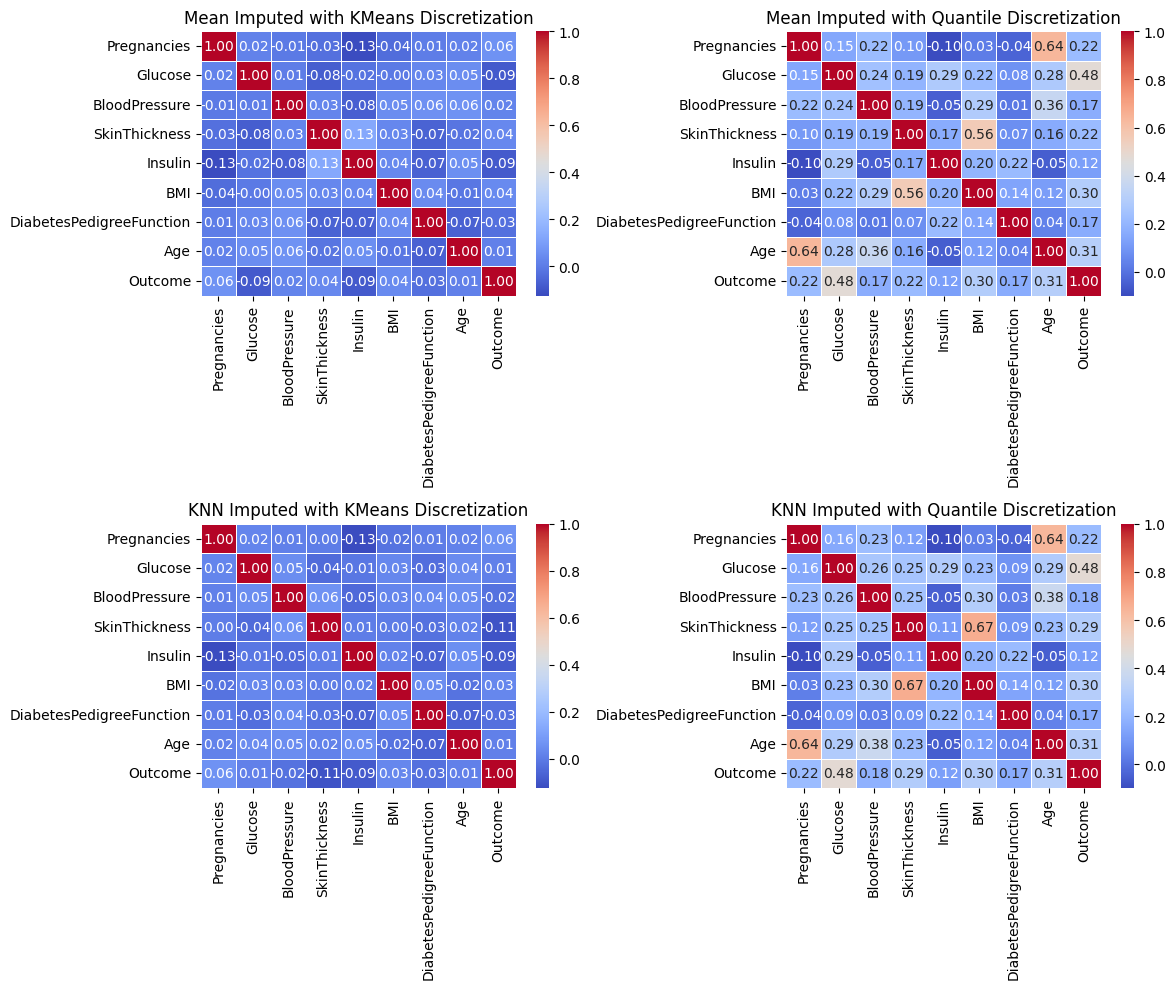

In [36]:
correlation_knn_kmeans = df_knn_kmeans.corr()
correlation_knn_quantile = df_knn_quantile.corr()
correlation_mean_kmeans = df_mean_kmeans.corr()
correlation_mean_quantile = df_mean_quantile.corr()
# plot all four correlation matrices
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.heatmap(correlation_mean_kmeans, annot=True, cmap='coolwarm', fmt=".2f", linewidth=.5)
plt.title('Mean Imputed with KMeans Discretization', fontsize=12)
plt.subplot(2, 2, 2)
sns.heatmap(correlation_mean_quantile, annot=True, cmap='coolwarm', fmt
=".2f", linewidth=.5)
plt.title('Mean Imputed with Quantile Discretization', fontsize=12)
plt.subplot(2, 2, 3)
sns.heatmap(correlation_knn_kmeans, annot=True, cmap='coolwarm',
    fmt=".2f", linewidth=.5)    
plt.title('KNN Imputed with KMeans Discretization', fontsize=12)
plt.subplot(2, 2, 4)
sns.heatmap(correlation_knn_quantile, annot=True, cmap='coolwarm',
    fmt=".2f", linewidth=.5)
plt.title('KNN Imputed with Quantile Discretization', fontsize=12)
plt.tight_layout()
plt.savefig('correlation_matrices_comparison.png')
plt.show()

### Pair plot of each changed feature vs Outcome


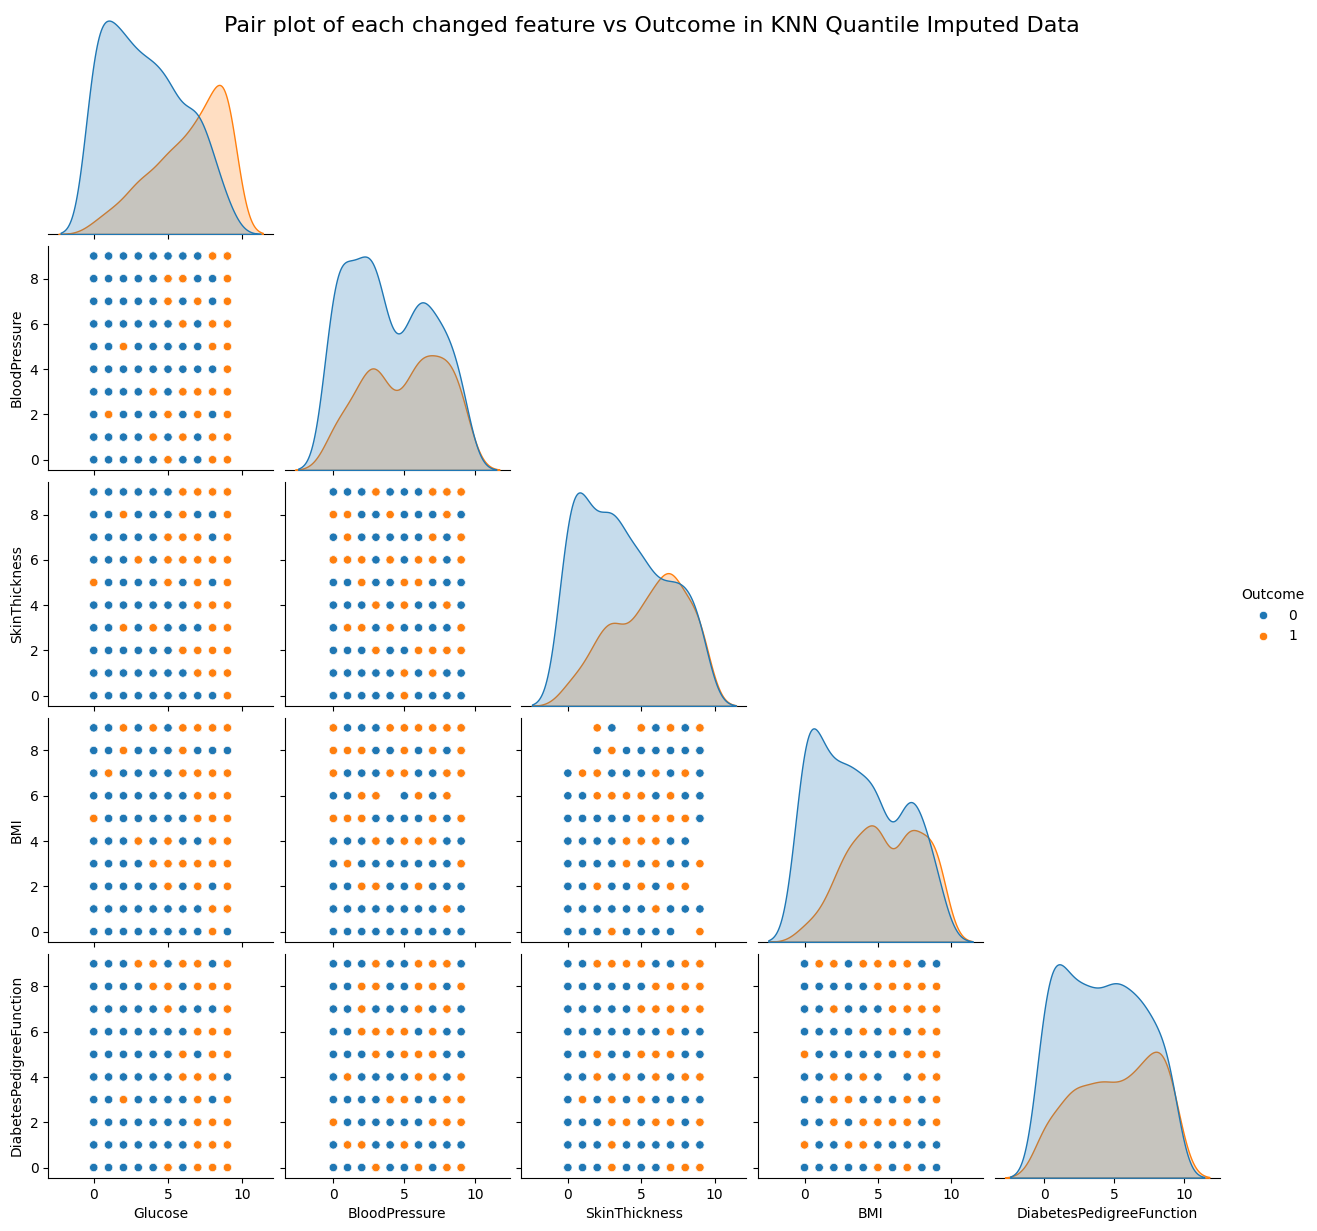

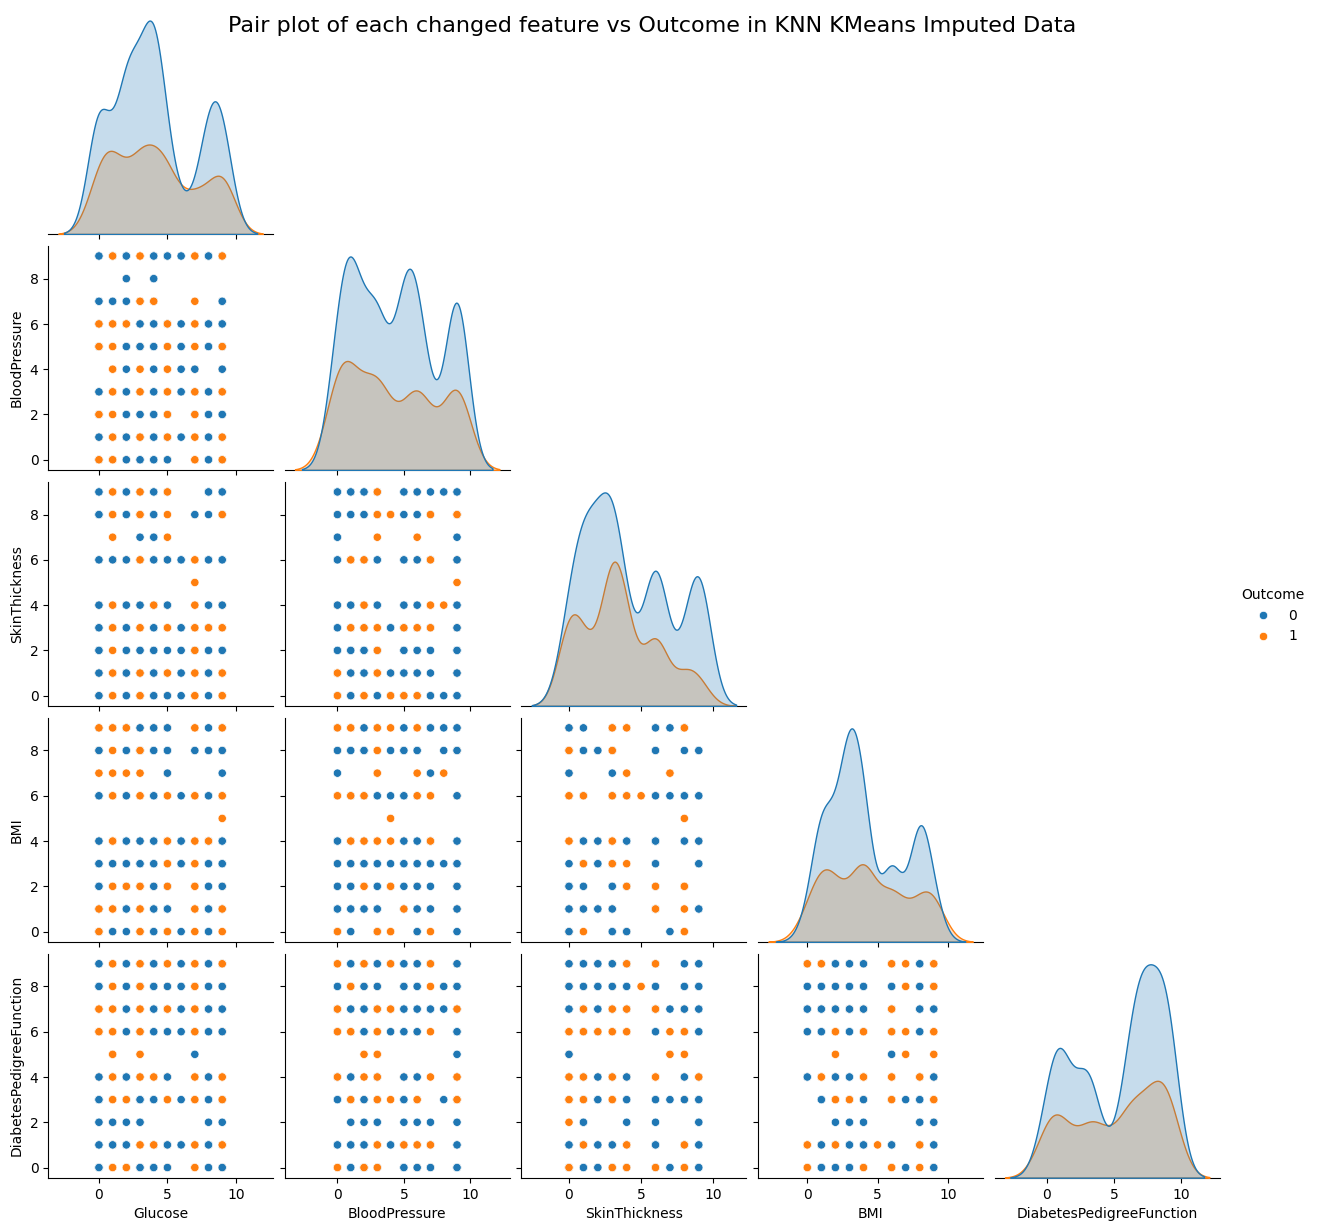

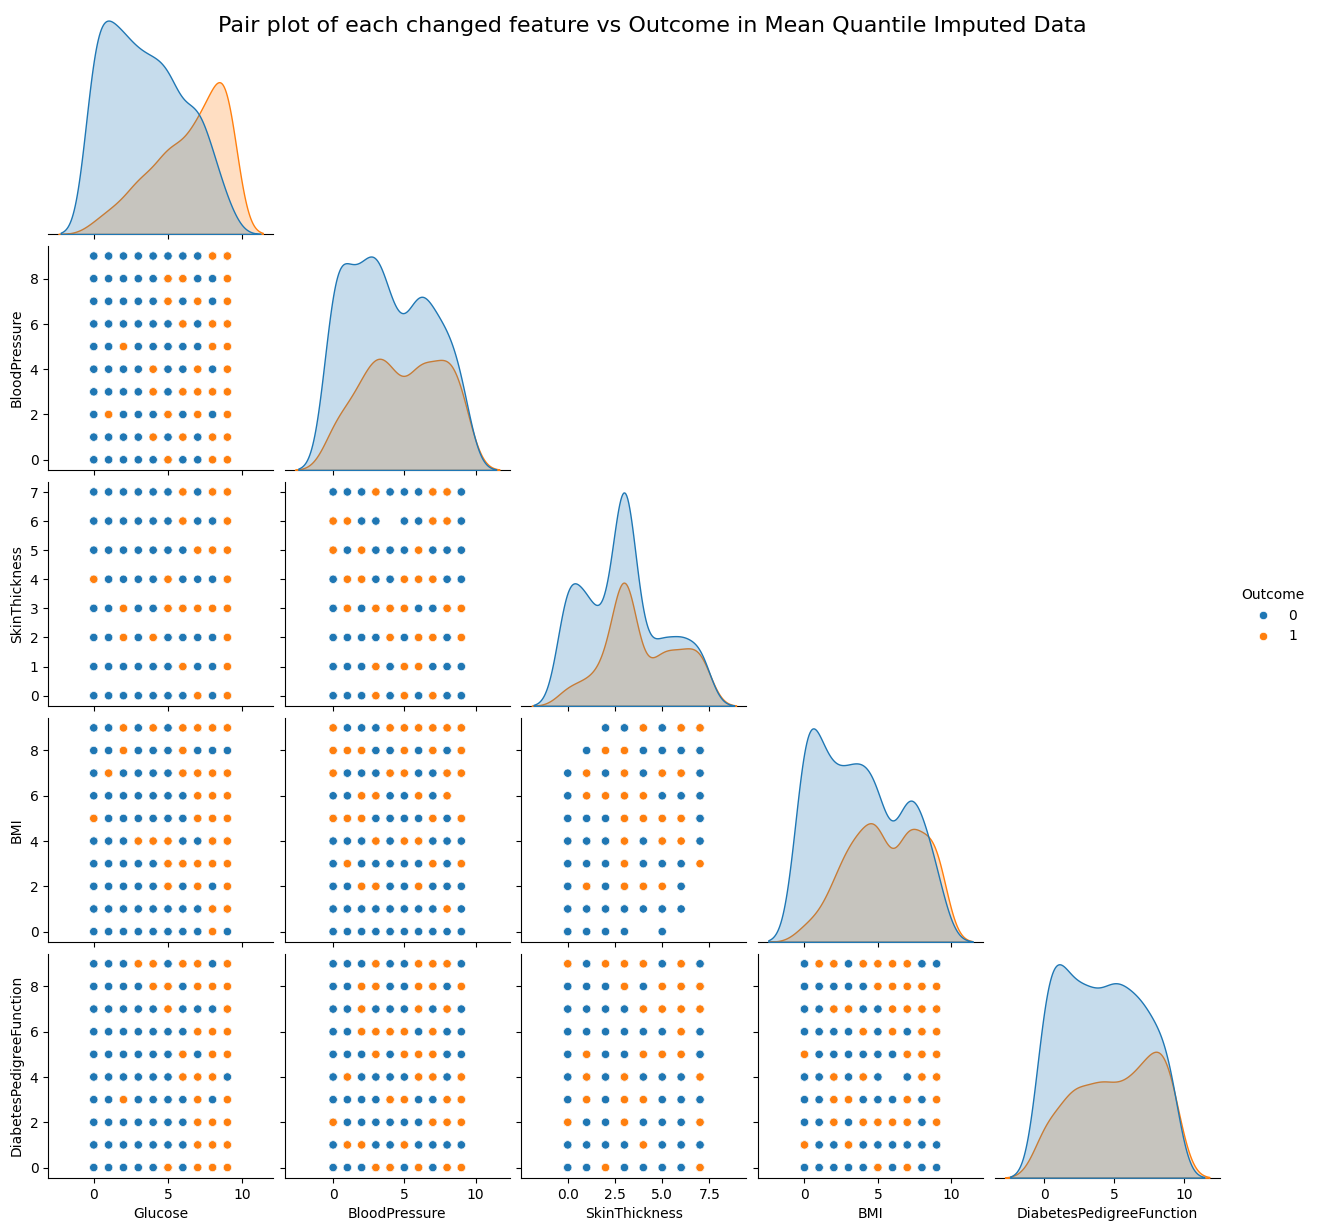

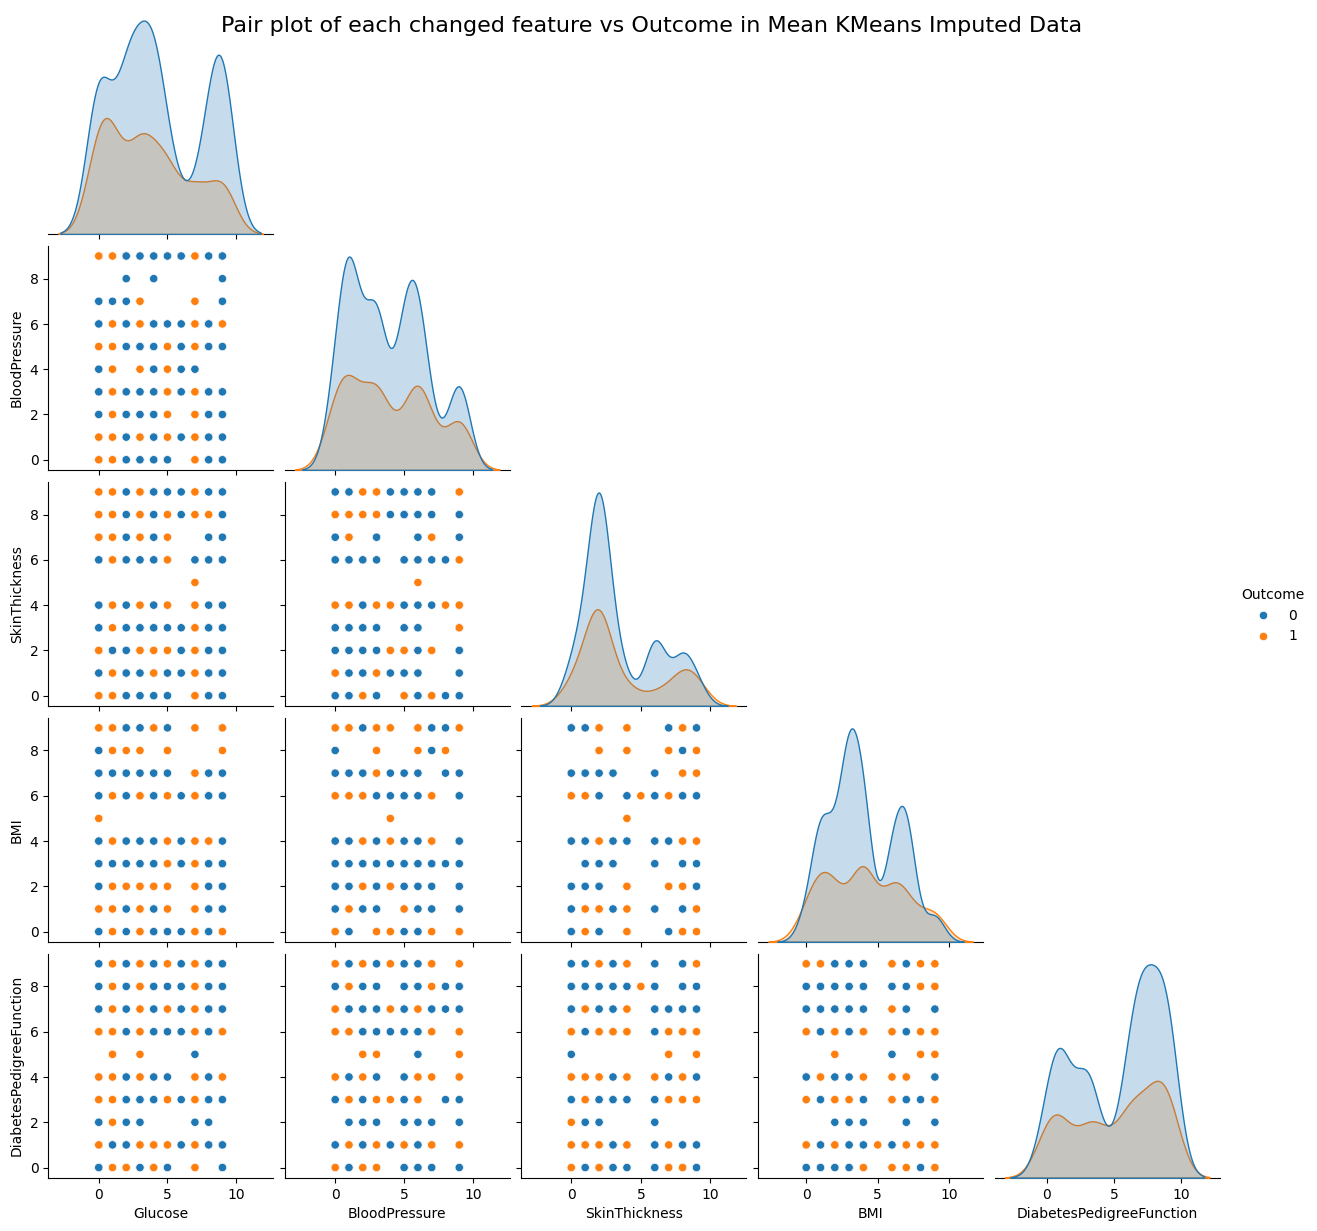

In [37]:
ploted_columns = columns_to_discretize_round + ["DiabetesPedigreeFunction"]
sns.pairplot(
    df_knn_quantile,
    vars=ploted_columns,
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair plot of each changed feature vs Outcome in KNN Quantile Imputed Data', fontsize=16)
plt.savefig('pair_plot_changed_features_vs_outcome_knn_quantile.png')
plt.show()
# knn kmeans
sns.pairplot(
    df_knn_kmeans,
    vars=ploted_columns,
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair plot of each changed feature vs Outcome in KNN KMeans Imputed Data', fontsize=16)
plt.savefig('pair_plot_changed_features_vs_outcome_knn_kmeans.png')
plt.show()
# mean quantile
sns.pairplot(
    df_mean_quantile,
    vars=ploted_columns,
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair plot of each changed feature vs Outcome in Mean Quantile Imputed Data', fontsize=16)
plt.savefig('pair_plot_changed_features_vs_outcome_mean_quantile.png')
plt.show()
# mean kmeans
sns.pairplot(
    df_mean_kmeans,
    vars=ploted_columns,
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair plot of each changed feature vs Outcome in Mean KMeans Imputed Data', fontsize=16)
plt.savefig('pair_plot_changed_features_vs_outcome_mean_kmeans.png')
plt.show()


## Training Bayesian Network

for Training Bayesian Network we will use pgmpy library. We will follow these steps:
1. Define the structure of the Bayesian Network which there is three options here:
   - we can define the structure manually based on domain knowledge.
   - we can use structure learning algorithms to learn the structure from data.
   - we can use a hybrid approach where we define some parts of the structure manually and learn other parts from data.
we will go through all three options and compare the results.

2. Define the Conditional Probability Distributions (CPDs) for each node in the network.
3. Perform inference on the Bayesian Network to make predictions about diabetes based on the input features.


### Define the structure of the Bayesian Network

#### Manually define the structure based on domain knowledge

in here we use the custom structure based on domain knowledge about diabetes.

This model will be our basic model which we connect the all features to the Outcome node directly. 

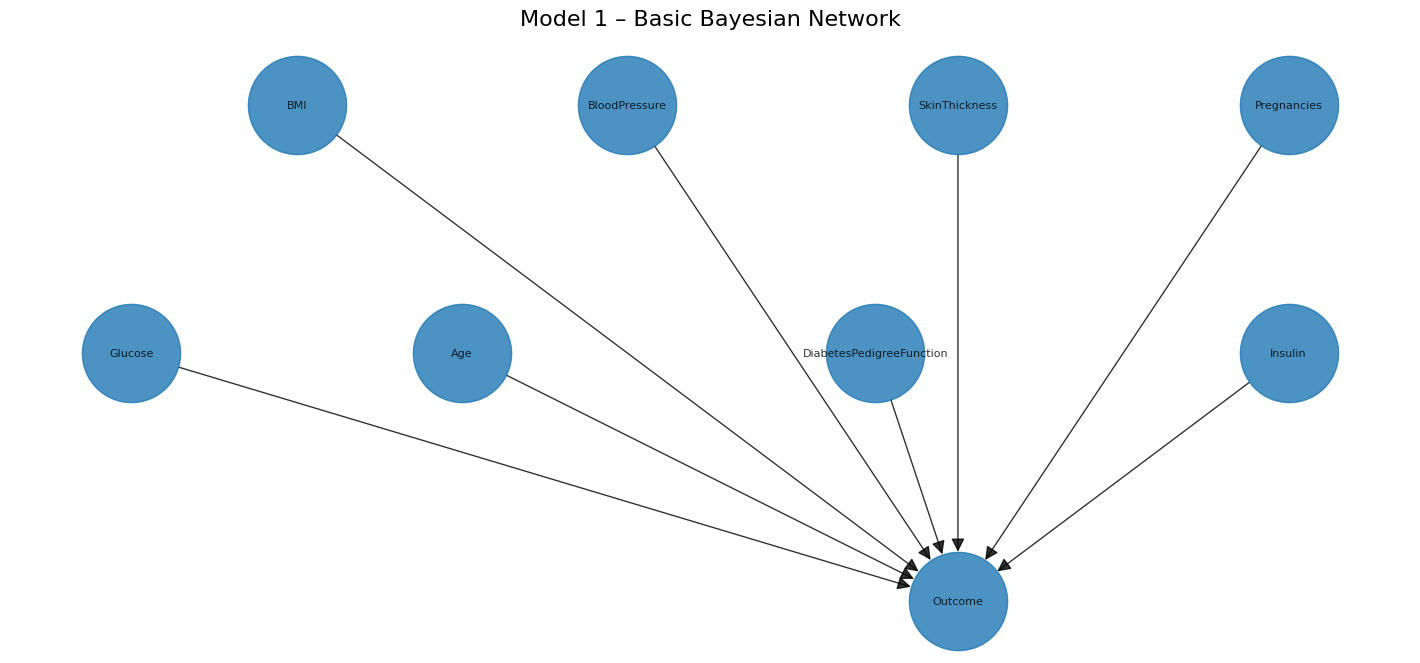

In [39]:
basic_model = DiscreteBayesianNetwork([
    ("Glucose", "Outcome"),
    ("BMI", "Outcome"),
    ("Age", "Outcome"),
    ("BloodPressure", "Outcome"),
    ("DiabetesPedigreeFunction", "Outcome") ,
    ("SkinThickness", "Outcome"),
    ("Insulin", "Outcome"),
    ("Pregnancies", "Outcome"),
    
])

pos_basic = {
    "Glucose": (0, 2), "BMI": (2, 4), "Age": (4, 2),
    "BloodPressure": (6, 4), "DiabetesPedigreeFunction": (9, 2), "SkinThickness": (10, 4),
    "Insulin": (14, 2), "Pregnancies": (14, 4),
    "Outcome": (10, 0)
}

plt.figure(figsize=(14, 6))
nx.draw(basic_model, pos_basic, with_labels=True, node_size=5000,
        font_size=8, arrowsize=20, alpha=0.8)

plt.title("Model 1 – Basic Bayesian Network", fontsize=16, pad=20)
plt.show()


Here is the second model where we connect the features based on their relations and influences on each other.

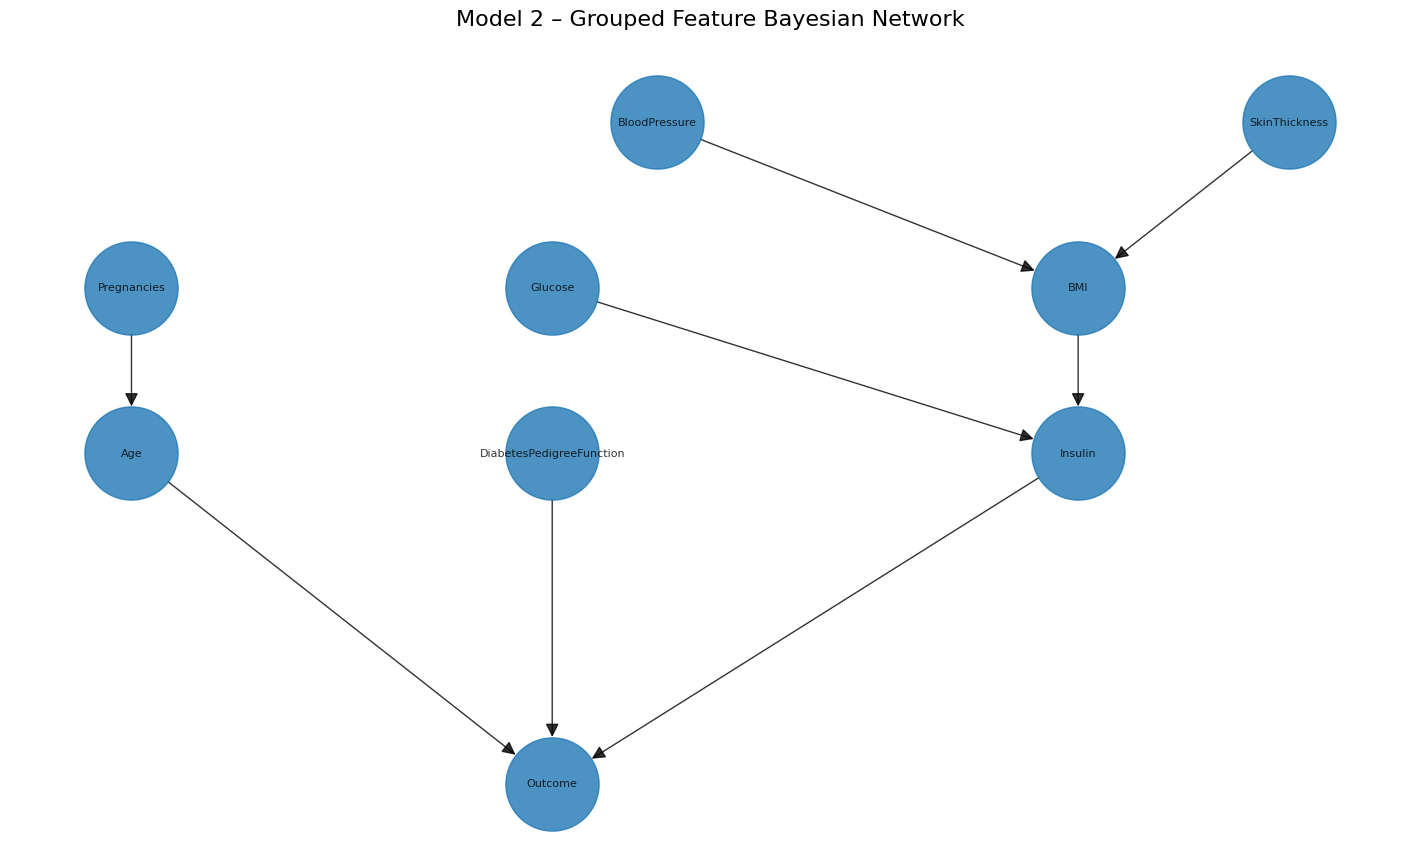

In [40]:
grouped_model = DiscreteBayesianNetwork([
   
    ("Glucose", "Insulin"),
    ("BMI", "Insulin"),
    ("SkinThickness", "BMI"),
    ("Pregnancies", "Age"),
    ("BloodPressure", "BMI"),
    ("DiabetesPedigreeFunction", "Outcome") ,
    ("Insulin", "Outcome"),
    ("Age", "Outcome"),

    
])

pos_grouped = {
   "Glucose": (5, 3), "BMI": (10, 3), "SkinThickness": (12, 4),
    "Age": (1, 2),
    "Pregnancies": (1, 3),
    "BloodPressure": (6, 4), "DiabetesPedigreeFunction": (5, 2), "Insulin": (10, 2),
    "Outcome": (5, 0),
   
}

plt.figure(figsize=(14, 8))
nx.draw(grouped_model, pos_grouped, with_labels=True, node_size=4500,
        font_size=8, arrowsize=20, alpha=0.8)

plt.title("Model 2 – Grouped Feature Bayesian Network", fontsize=16, pad=20)
plt.show()


Here we use the structure learning algorithm to learn the structure from data.
First we will use Tree Search algorithm to learn the structure from data.
Then we will use Hill Climb Search algorithm to learn the structure from data.

We need to define the models for each data preprocessing method we used before:
1. Mean Imputation + Quantile Binning
2. Mean Imputation + K-Means Binning
3. KNN Imputation + Quantile Binning
4. KNN Imputation + K-Means Binning

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'SkinThickness': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
Building tree: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36.0 [00:00<00:00, 38.04it/s]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'SkinThickness': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
Building tree: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36.0 [00:00<00:00, 10259.20it/s]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) infer

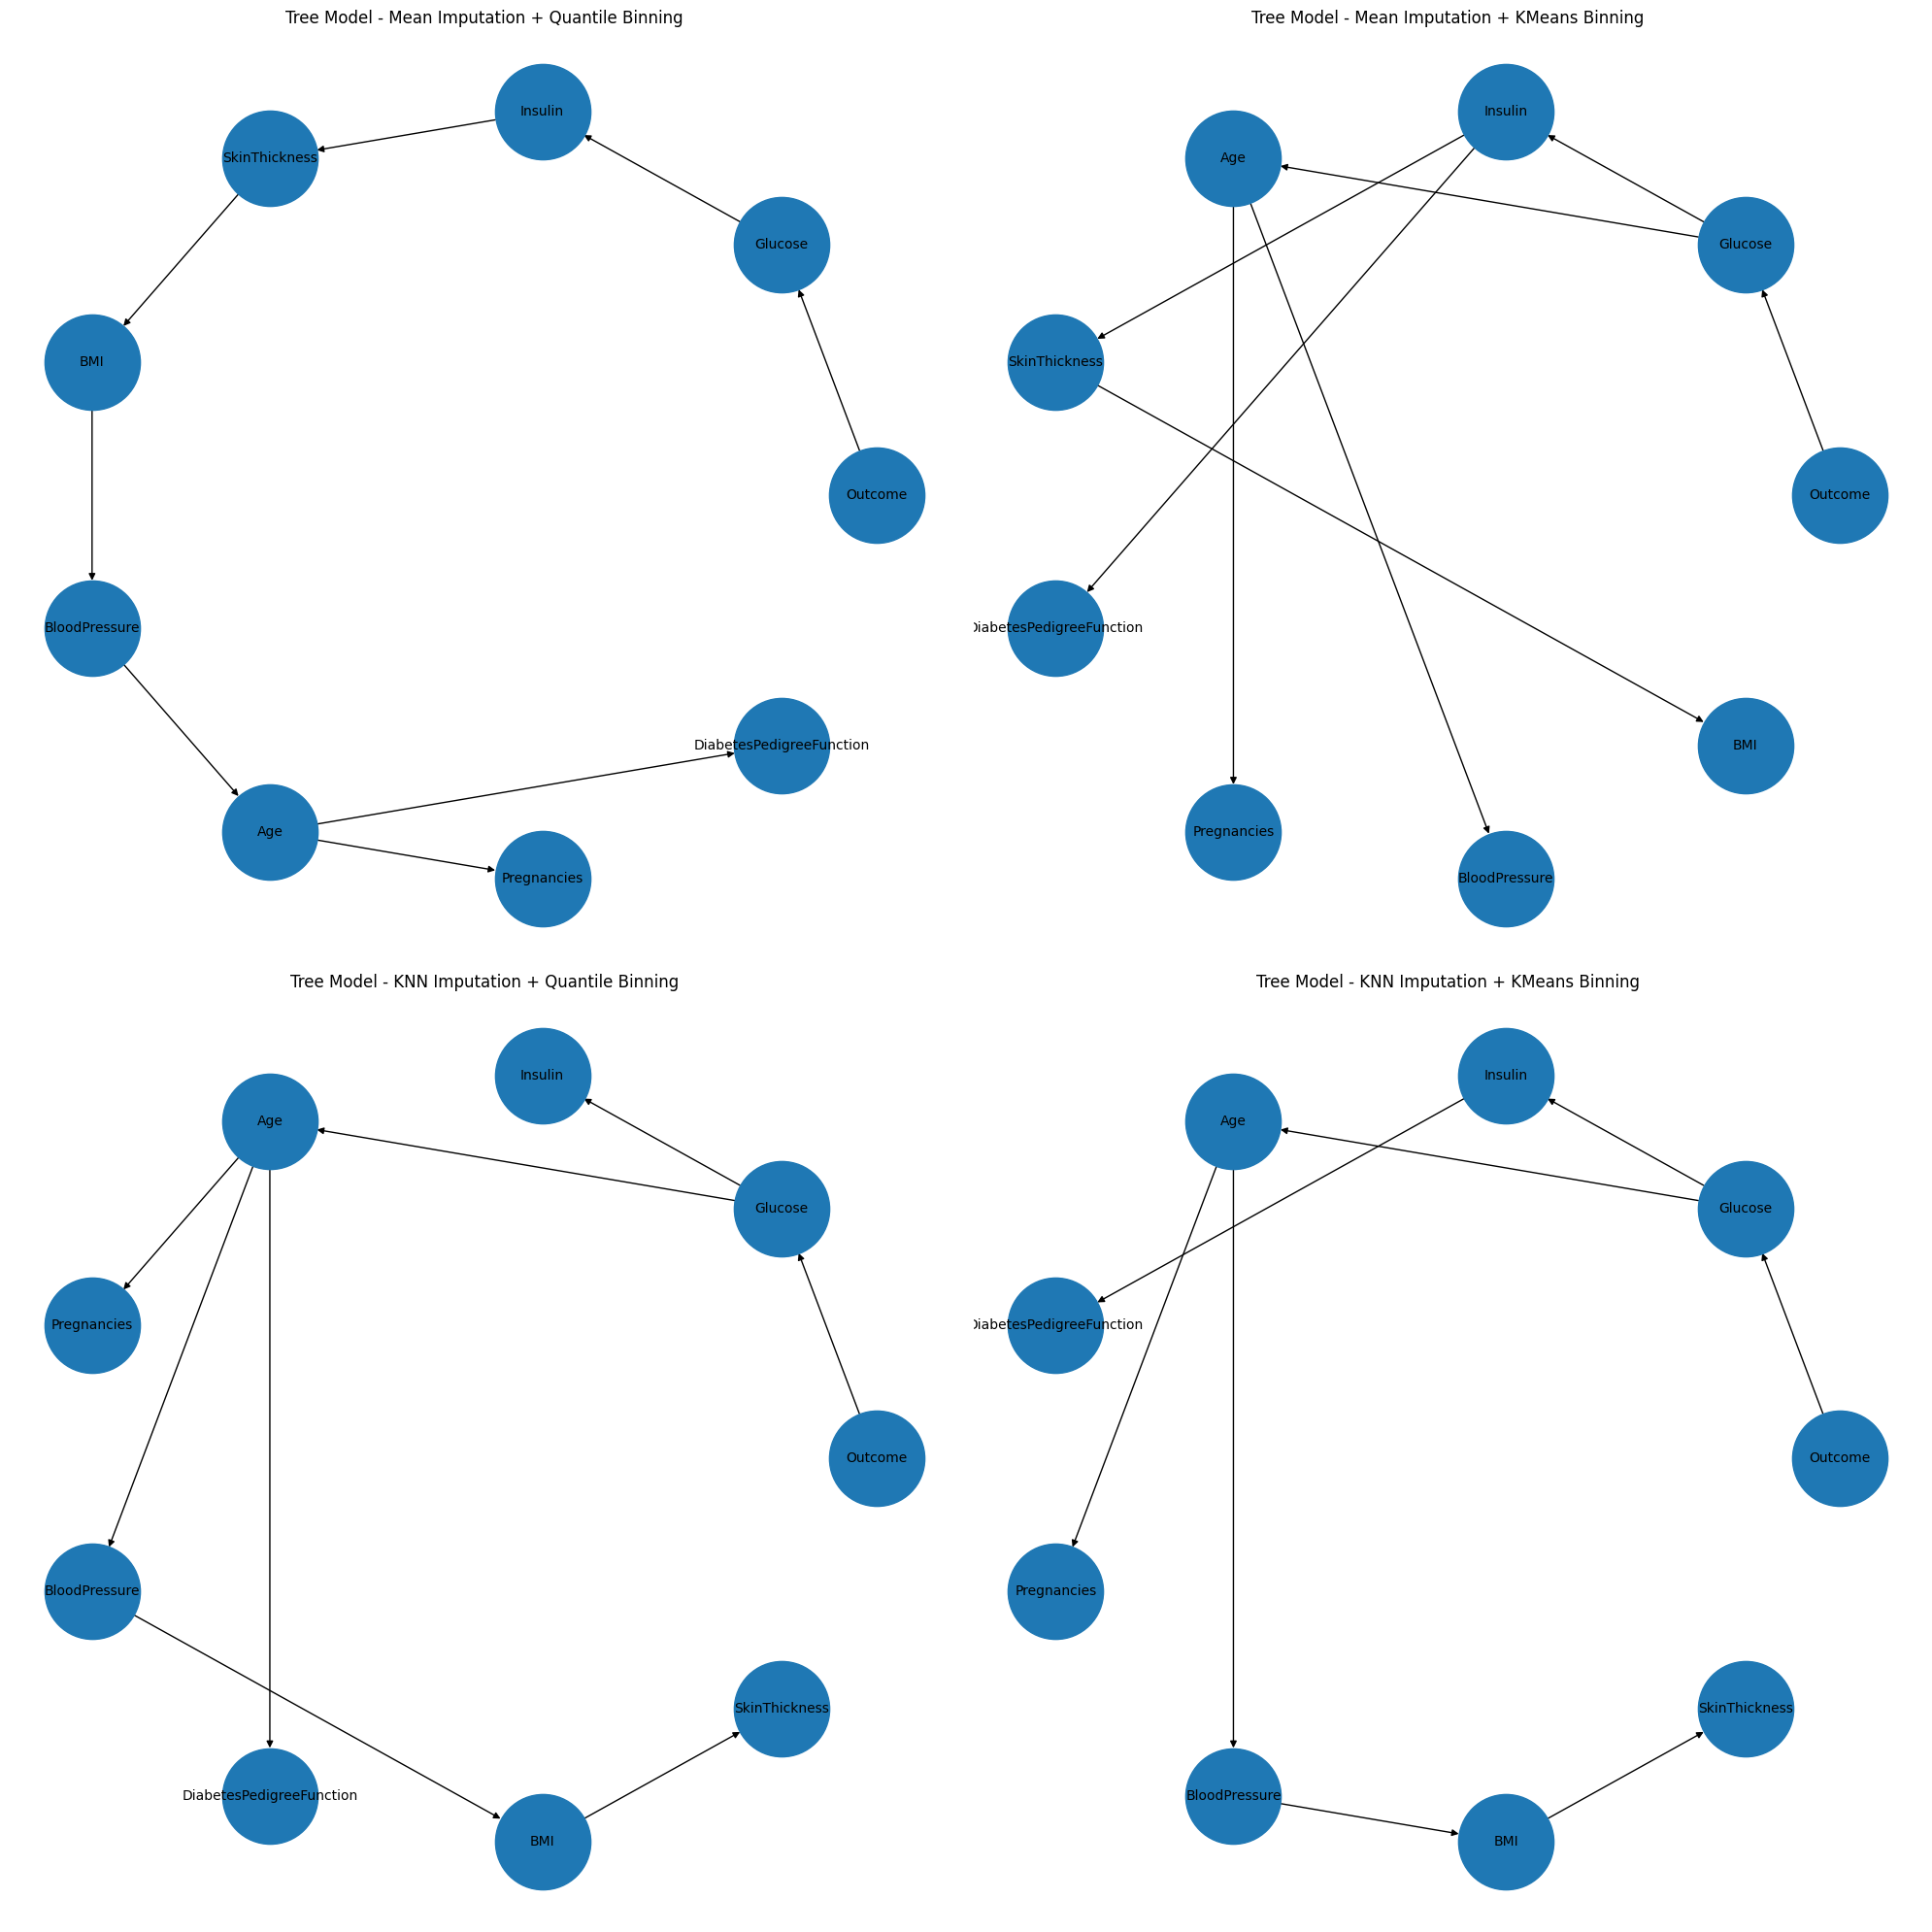

In [41]:
# method 1: Mean Imputation + Quantile Binning
ts_mean_quantile = TreeSearch(data=df_mean_quantile, root_node="Outcome")
tree_model_mean_quantile = ts_mean_quantile.estimate(show_progress=True)
# method 2: Mean Imputation + KMeans Binning
ts_mean_kmeans = TreeSearch(data=df_mean_kmeans, root_node="Outcome")
tree_model_mean_kmeans = ts_mean_kmeans.estimate(show_progress=True)
# method 3: KNN Imputation + Quantile Binning
ts_knn_quantile = TreeSearch(data=df_knn_quantile, root_node="Outcome")
tree_model_knn_quantile = ts_knn_quantile.estimate(show_progress=True)
# method 4: KNN Imputation + KMeans Binning
ts_knn_kmeans = TreeSearch(data=df_knn_kmeans, root_node="Outcome")
tree_model_knn_kmeans = ts_knn_kmeans.estimate(show_progress=True)
# draw all four tree models
tree_models = [
    (tree_model_mean_quantile, 'Tree Model - Mean Imputation + Quantile Binning'),
    (tree_model_mean_kmeans, 'Tree Model - Mean Imputation + KMeans Binning'),
    (tree_model_knn_quantile, 'Tree Model - KNN Imputation + Quantile Binning'),
    (tree_model_knn_kmeans, 'Tree Model - KNN Imputation + KMeans Binning')
]
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes = axes.flatten()

for ax, (tree_model, title) in zip(axes, tree_models):
    pos = nx.drawing.layout.circular_layout(tree_model)

    nx.draw_networkx(
        tree_model,
        pos=pos,
        ax=ax,
        node_size=5000,
        font_size=10
    )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig("all_tree_models.png")
plt.show()
# define bayesian models based on learned structures
tree_models = {
    'Mean_Quantile': DiscreteBayesianNetwork(tree_model_mean_quantile.edges()),
    'Mean_KMeans': DiscreteBayesianNetwork(tree_model_mean_kmeans.edges()),
    'KNN_Quantile': DiscreteBayesianNetwork(tree_model_knn_quantile.edges()),
    'KNN_KMeans': DiscreteBayesianNetwork(tree_model_knn_kmeans.edges())
}


Here we do a high climb search with diffrent scoring methods.
- k2
- bdeu
- bic
- bds
- AIC 

we have diffrent scoring methods and at all we have 20 diffrent models to compare plus 4 models from tree search and 2 custom models.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'SkinThickness': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'SkinThickness': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'SkinThickness': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'SkinThickn

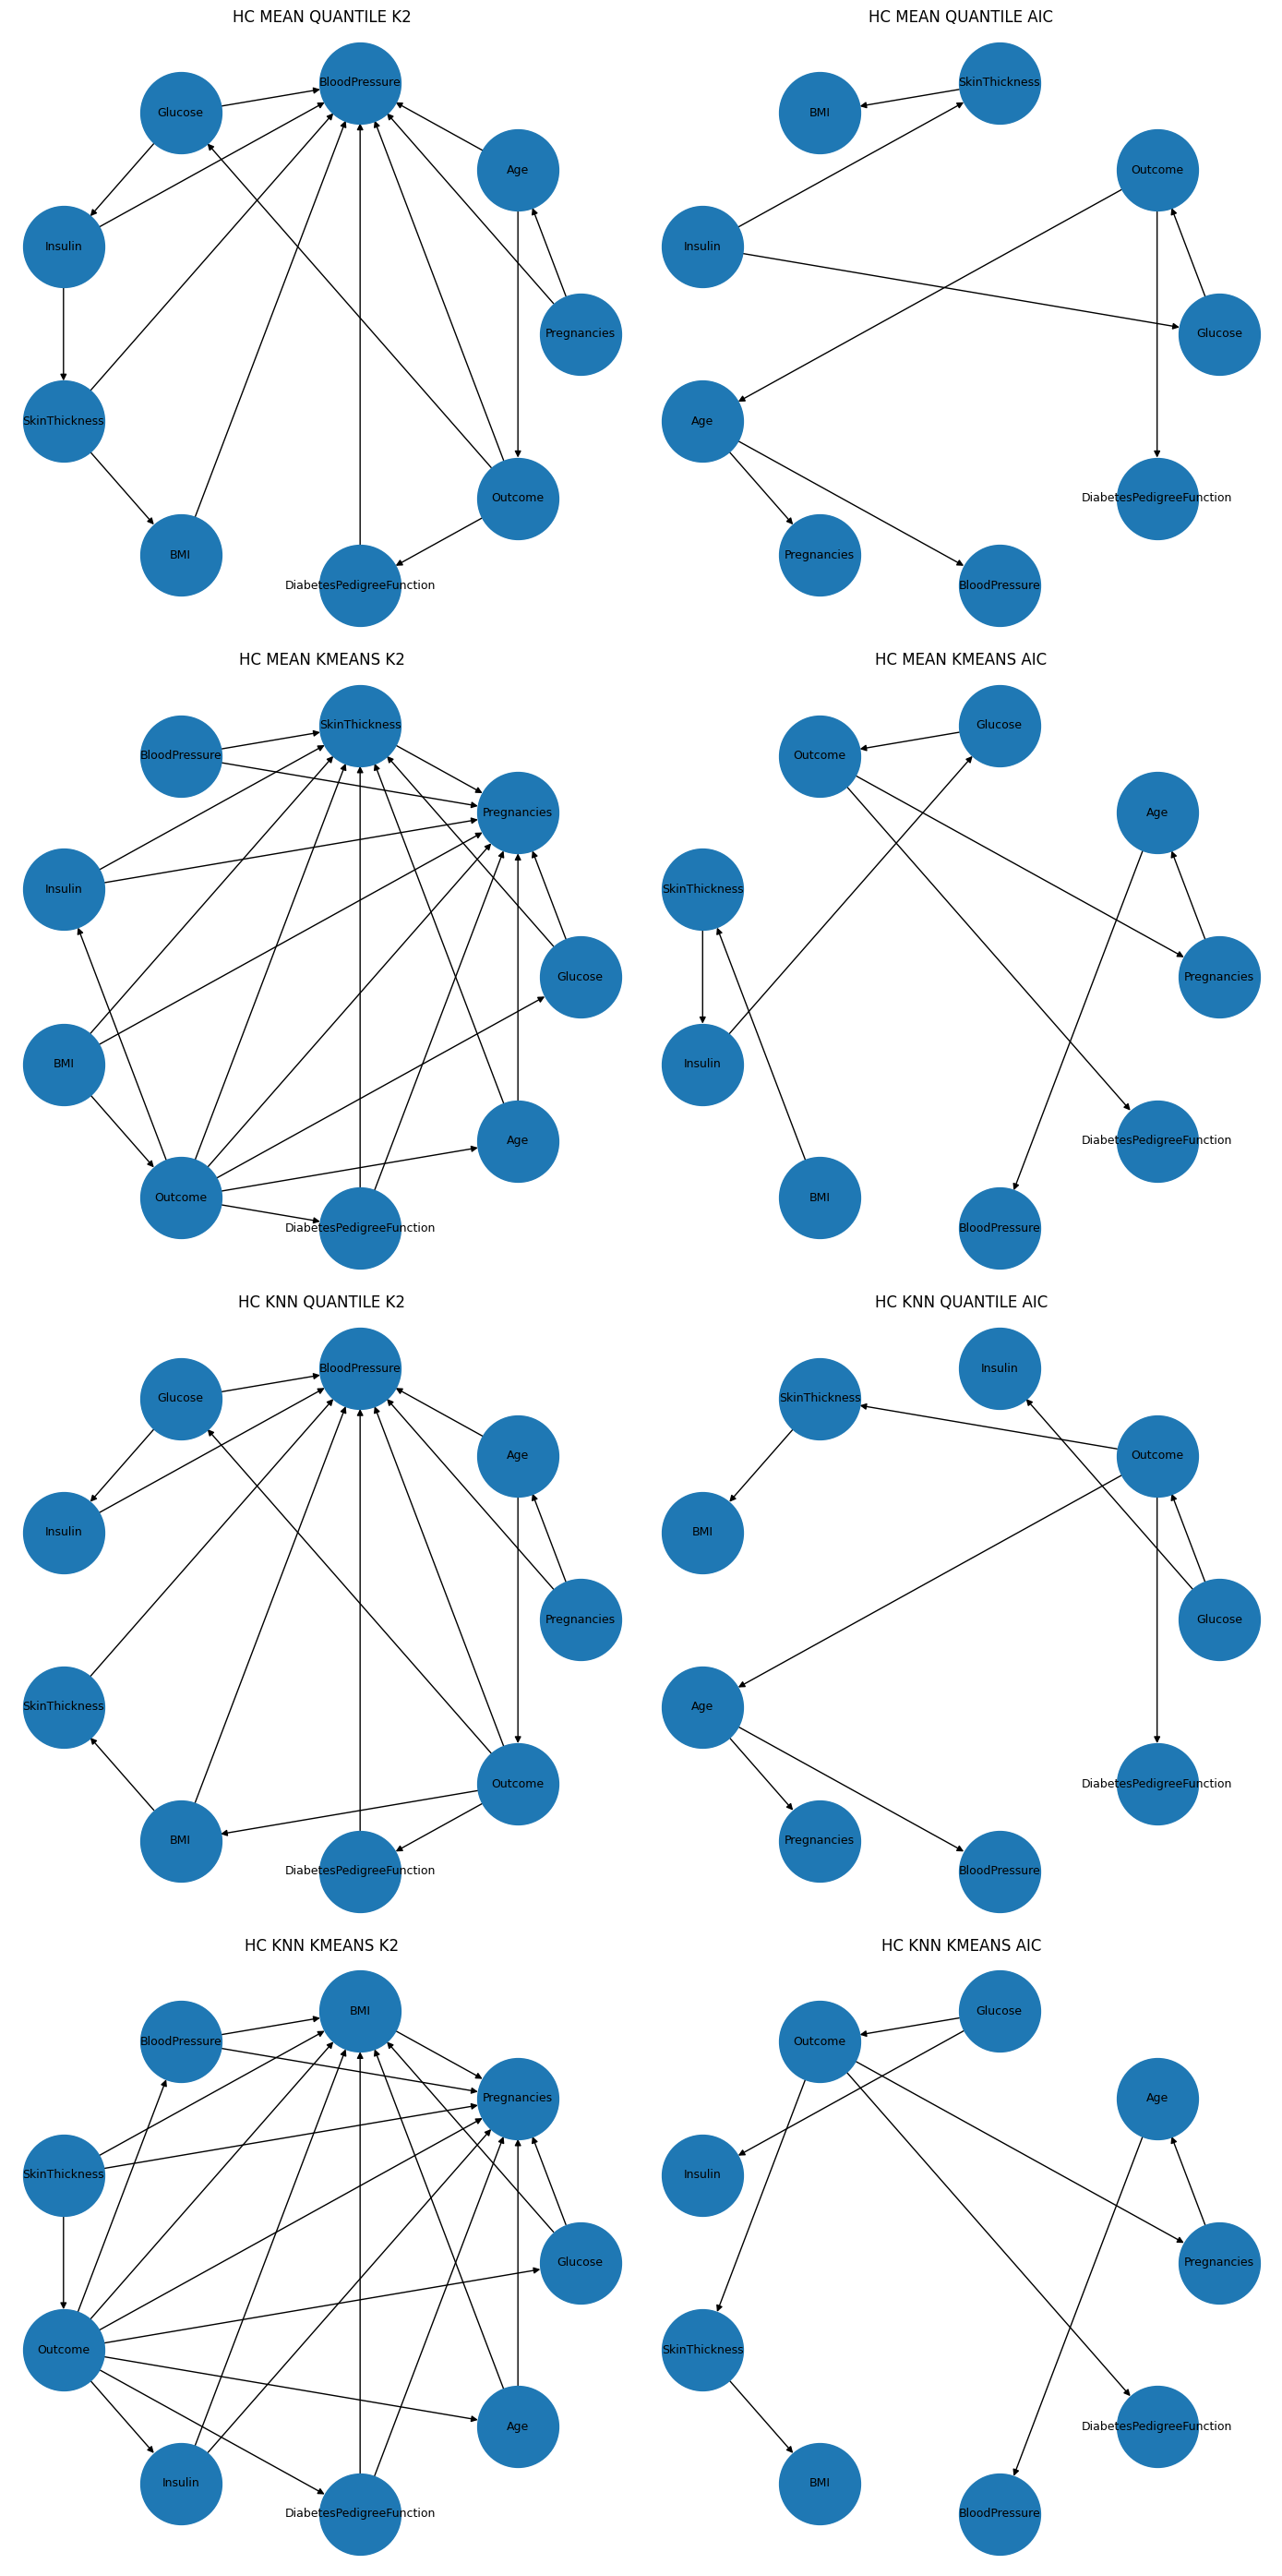

In [42]:
scorers = ['k2', 'aic']
data_types = {
    'Mean_Quantile': df_mean_quantile,
    'Mean_KMeans': df_mean_kmeans,
    'KNN_Quantile': df_knn_quantile,
    'KNN_KMeans': df_knn_kmeans
}

hc_models = {}

for data_type, data in data_types.items():
    for scorer_name in scorers:
        if scorer_name == 'k2':
            scorer = K2(data)
        elif scorer_name == 'aic':
            scorer = AIC(data)
        hc = HillClimbSearch(data=data)
        hc_model = hc.estimate(scoring_method=scorer, show_progress=False)
        model_key = f'hc_{data_type.lower()}_{scorer_name}'
        hc_models[model_key] = DiscreteBayesianNetwork(hc_model.edges())
        # plot the all models in one figure

import math
import matplotlib.pyplot as plt
import networkx as nx


fig, axes = plt.subplots(
    4,
    2,
    figsize=(7 * 2, 7 * 4)
)

axes = axes.flatten()

for ax, (model_key, hc_model) in zip(axes, hc_models.items()):
    pos = nx.drawing.layout.circular_layout(hc_model)

    nx.draw_networkx(
        hc_model,
        pos=pos,
        ax=ax,
        node_size=4000,
        font_size=9
    )

    title = model_key.replace('_', ' ').upper()
    ax.set_title(title)
    ax.axis("off")

# Hide unused subplots (if any)
for ax in axes[len(hc_models):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("all_hill_climb_models.png")
plt.show()




we saw that only k2 and AIC scoring methods were able to converg to a model for all four datasets.

We will remove other scoring methods from comparison.

In [43]:
hc_models = {k: v for k, v in hc_models.items() if 'k2' in k or 'aic' in k}
hc_models

{'hc_mean_quantile_k2': <pgmpy.models.DiscreteBayesianNetwork.DiscreteBayesianNetwork at 0x34b099420>,
 'hc_mean_quantile_aic': <pgmpy.models.DiscreteBayesianNetwork.DiscreteBayesianNetwork at 0x34988a950>,
 'hc_mean_kmeans_k2': <pgmpy.models.DiscreteBayesianNetwork.DiscreteBayesianNetwork at 0x35032b040>,
 'hc_mean_kmeans_aic': <pgmpy.models.DiscreteBayesianNetwork.DiscreteBayesianNetwork at 0x34cae7040>,
 'hc_knn_quantile_k2': <pgmpy.models.DiscreteBayesianNetwork.DiscreteBayesianNetwork at 0x34b9956c0>,
 'hc_knn_quantile_aic': <pgmpy.models.DiscreteBayesianNetwork.DiscreteBayesianNetwork at 0x35bbb9060>,
 'hc_knn_kmeans_k2': <pgmpy.models.DiscreteBayesianNetwork.DiscreteBayesianNetwork at 0x349889de0>,
 'hc_knn_kmeans_aic': <pgmpy.models.DiscreteBayesianNetwork.DiscreteBayesianNetwork at 0x34ca8dd50>}

In [ ]:

models = [('basic_mean_quantile', basic_model),
          ('basic_mean_kmeans', basic_model),
          ('basic_knn_quantile', basic_model),
            ('basic_knn_kmeans', basic_model),
          ('grouped_mean_quantile', grouped_model),
            ('grouped_mean_kmeans', grouped_model),
            ('grouped_knn_quantile', grouped_model),
            ('grouped_knn_kmeans', grouped_model),
          ('tree_mean_quantile', tree_models['Mean_Quantile']),
            ('tree_mean_kmeans', tree_models['Mean_KMeans']),
            ('tree_knn_quantile', tree_models['KNN_Quantile']),
            ('tree_knn_kmeans', tree_models['KNN_KMeans']),
            ('hc_mean_quantile_k2', hc_models['hc_mean_quantile_k2']),
            ('hc_mean_kmeans_k2', hc_models['hc_mean_kmeans_k2']),
            ('hc_knn_quantile_k2', hc_models['hc_knn_quantile_k2']),
            ('hc_knn_kmeans_k2', hc_models['hc_knn_kmeans_k2']),
            ('hc_mean_quantile_aic', hc_models['hc_mean_quantile_aic']),
            ('hc_mean_kmeans_aic', hc_models['hc_mean_kmeans_aic']),
            ('hc_knn_quantile_aic', hc_models['hc_knn_quantile_aic']),
            ('hc_knn_kmeans_aic', hc_models['hc_knn_kmeans_aic'])]
data_map = {
    'basic_mean_quantile': df_mean_quantile,
    'basic_mean_kmeans': df_mean_kmeans,
    'basic_knn_quantile': df_knn_quantile,
    'basic_knn_kmeans': df_knn_kmeans,
    'grouped_mean_quantile': df_mean_quantile,
    'grouped_mean_kmeans': df_mean_kmeans,
    'grouped_knn_quantile': df_knn_quantile,
    'grouped_knn_kmeans': df_knn_kmeans,
    'tree_mean_quantile': df_mean_quantile,
    'tree_mean_kmeans': df_mean_kmeans,
    'tree_knn_quantile': df_knn_quantile,
    'tree_knn_kmeans': df_knn_kmeans,
    'hc_mean_quantile_k2': df_mean_quantile,
    'hc_mean_kmeans_k2': df_mean_kmeans,
    'hc_knn_quantile_k2': df_knn_quantile,
    'hc_knn_kmeans_k2': df_knn_kmeans,
    'hc_mean_quantile_aic': df_mean_quantile,
    'hc_mean_kmeans_aic': df_mean_kmeans,
    'hc_knn_quantile_aic': df_knn_quantile,
    'hc_knn_kmeans_aic': df_knn_kmeans
}
for name, model in models:
    print(f'Computing CDTs for {name} model')
    model.fit(data_map[name], estimator=MaximumLikelihoodEstimator)



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'SkinThickness': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}


Computing CDTs for basic_mean_quantile model


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'SkinThickness': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}


Computing CDTs for basic_mean_kmeans model


In [ ]:
nodes = ['alcohol', 'sulphates', 'volatile acidity',
         'citric acid', 'residual sugar', 'chlorides',
         'density', 'pH', 'free sulfur dioxide',
         'total sulfur dioxide', 'fixed acidity', 'quality']
print('Considering nodes:', nodes)
for name, model in models:
    print(f'Analyzing model: {name}')
    print(f'The total number of valid independence assertions is {len(model.get_independencies().get_assertions())}')
    print(f'Local semantics of the current model:\n{model.local_independencies(nodes)}')
    print('Checking Markov blankets')
    for node in nodes:
        print(f'The Markov blanket of node {node} is {model.get_markov_blanket(node)}')
    print()

Considering nodes: ['alcohol', 'sulphates', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'density', 'pH', 'free sulfur dioxide', 'total sulfur dioxide', 'fixed acidity', 'quality']
Analyzing model: basic_model
The total number of valid independence assertions is 55
Local semantics of the current model:
(alcohol ⟂ fixed acidity, citric acid, pH, density, chlorides, residual sugar, volatile acidity, sulphates, free sulfur dioxide, total sulfur dioxide)
(sulphates ⟂ fixed acidity, citric acid, pH, density, chlorides, residual sugar, volatile acidity, alcohol, free sulfur dioxide, total sulfur dioxide)
(volatile acidity ⟂ fixed acidity, citric acid, pH, density, chlorides, residual sugar, alcohol, sulphates, free sulfur dioxide, total sulfur dioxide)
(citric acid ⟂ fixed acidity, pH, density, chlorides, residual sugar, volatile acidity, alcohol, sulphates, free sulfur dioxide, total sulfur dioxide)
(residual sugar ⟂ fixed acidity, citric acid, pH, density, chlorides, v

In [ ]:
inferences = [(name, VariableElimination(model)) for name, model in models]